<img src="../Decorative-Elements/Section-05/ADL-S05-Image-01.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/06-SEI-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/02-Planet-Packing.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-05/ADL-S05-Image-02.png">
<img src="../Decorative-Elements/Section-05/ADL-S05-Image-03-a.png">

In [1]:
# Tides on Earth - Comment 

# Tides are the periodic rise and fall of sea levels along coastlines. 
# They are primarily caused by the gravitational interactions between the Earth, Moon, and Sun.

# 1. Gravitational Pull:
#    - The Moon exerts a gravitational force on Earth.
#    - Water in the oceans is fluid, so it responds more noticeably than the solid Earth.
#    - The side of Earth facing the Moon experiences a stronger pull, creating a "bulge" of water: the high tide.

# 2. Opposite Side Bulge:
#    - The side opposite the Moon also experiences a high tide.
#    - This is due to the centrifugal force arising from the Earth-Moon system rotating around a common center of mass.

# 3. Sun’s Influence:
#    - The Sun also exerts gravitational forces, though weaker than the Moon due to distance.
#    - When the Sun, Moon, and Earth align (full moon or new moon), the tides are higher (spring tides).
#    - When the Sun and Moon are at right angles relative to Earth (first and third quarters), tides are lower (neap tides).

# 4. Factors Affecting Tides:
#    - Local geography: shape of coastlines, ocean depth, and seabed topography.
#    - Rotation of Earth: causes tidal bulges to move, producing high and low tides at different times.
#    - Inclination of the Moon’s orbit: affects the height and timing of tides.

# 5. Types of Tides:
#    - Semi-diurnal: two high and two low tides each day (most common).
#    - Diurnal: one high and one low tide each day.
#    - Mixed: combination of diurnal and semi-diurnal characteristics.

# 6. Summary:
#    - Tides are a result of the combination of gravitational forces and rotational effects.
#    - Moon has the dominant effect; Sun contributes significantly.
#    - Tidal patterns vary around the world due to geography and Earth's rotation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

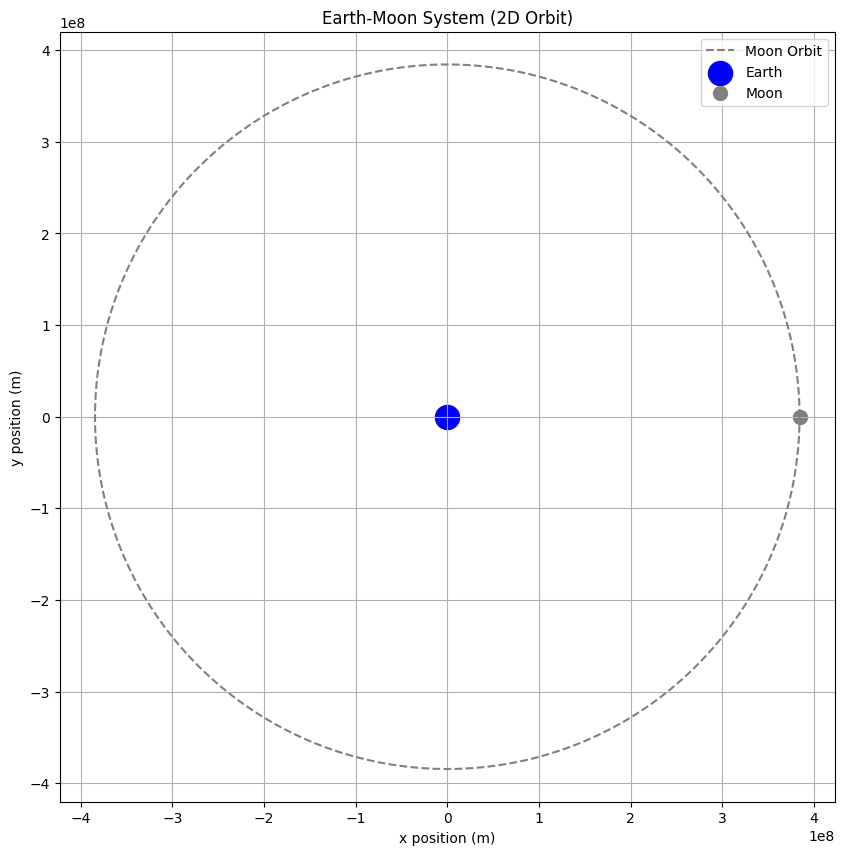

In [3]:
# Earth-Moon System: 2D Orbit Grid
# Physical constants
R_earth = 6.371e6       # radius of Earth, meters
d_em = 384400e3         # average distance from Earth to Moon, meters
M_earth = 5.972e24      # mass of Earth, kg
M_moon = 7.34767309e22  # mass of Moon, kg

# Define positions (2D) assuming circular orbit in xy-plane
theta = np.linspace(0, 2*np.pi, 500)  # angle for orbit

# Earth at origin
x_earth = 0
y_earth = 0

# Moon's circular orbit
x_moon = d_em * np.cos(theta)
y_moon = d_em * np.sin(theta)

# Plotting the Earth and Moon orbit
plt.figure(figsize=(10,10))
plt.plot(x_moon, y_moon, color='gray', linestyle='--', label='Moon Orbit')
plt.scatter(x_earth, y_earth, color='blue', s=300, label='Earth')
plt.scatter(x_moon[0], y_moon[0], color='gray', s=100, label='Moon')

# Formatting the plot
plt.title('Earth-Moon System (2D Orbit)')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.axis('equal')  # equal scale for x and y
plt.grid(True)
plt.legend()
plt.legend(loc='upper right')
plt.show()

Time (days):
[ 0.          0.05470942  0.10941884  0.16412826  0.21883768  0.27354709
  0.32825651  0.38296593  0.43767535  0.49238477  0.54709419  0.60180361
  0.65651303  0.71122244  0.76593186  0.82064128  0.8753507   0.93006012
  0.98476954  1.03947896  1.09418838  1.1488978   1.20360721  1.25831663
  1.31302605  1.36773547  1.42244489  1.47715431  1.53186373  1.58657315
  1.64128257  1.69599198  1.7507014   1.80541082  1.86012024  1.91482966
  1.96953908  2.0242485   2.07895792  2.13366733  2.18837675  2.24308617
  2.29779559  2.35250501  2.40721443  2.46192385  2.51663327  2.57134269
  2.6260521   2.68076152  2.73547094  2.79018036  2.84488978  2.8995992
  2.95430862  3.00901804  3.06372745  3.11843687  3.17314629  3.22785571
  3.28256513  3.33727455  3.39198397  3.44669339  3.50140281  3.55611222
  3.61082164  3.66553106  3.72024048  3.7749499   3.82965932  3.88436874
  3.93907816  3.99378758  4.04849699  4.10320641  4.15791583  4.21262525
  4.26733467  4.32204409  4.37675351  4

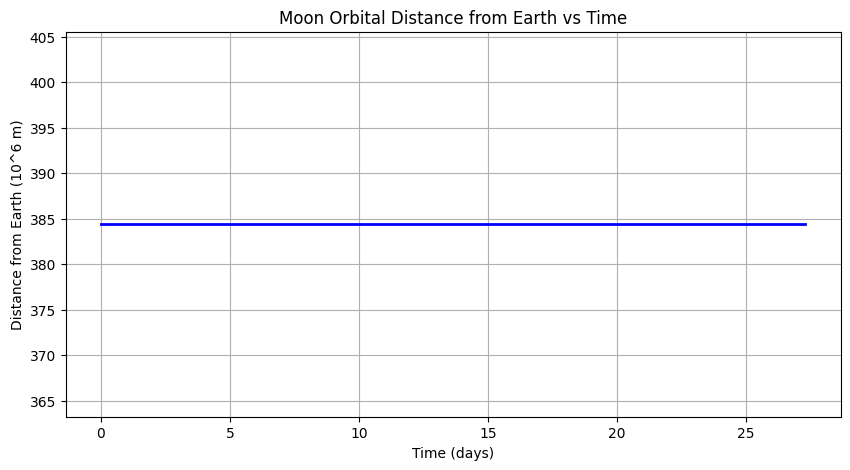

In [4]:
# Time vs Moon's orbital distance from Earth with printed time
# Physical constants
d_em = 384400e3       # average Earth-Moon distance, meters
T_moon = 27.3         # Moon orbital period in days

# Time array (simulate one orbit)
t_days = np.linspace(0, T_moon, 500)       # in days

# For circular orbit, distance is constant
orbital_distance = np.ones_like(t_days) * d_em

# Print the time array
print("Time (days):")
print(t_days)

# Plotting
plt.figure(figsize=(10,5))
plt.plot(t_days, orbital_distance/1e6, color='blue', lw=2)
plt.title('Moon Orbital Distance from Earth vs Time')
plt.xlabel('Time (days)')
plt.ylabel('Distance from Earth (10^6 m)')
plt.grid(True)
plt.show()

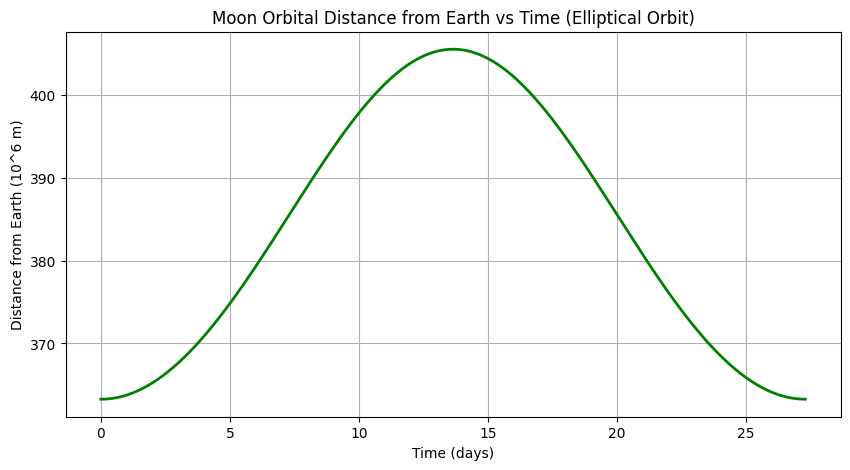

Minimum distance (perigee): 363.26 million m
Maximum distance (apogee): 405.54 million m


In [5]:
# Time vs Moon's orbital distance (Elliptical Orbit)
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
d_em = 384400e3          # average Earth-Moon distance, meters
ecc = 0.055              # Moon's orbital eccentricity
T_moon = 27.3            # orbital period in days

# Time array over one lunar month
t_days = np.linspace(0, T_moon, 500)

# Elliptical orbit distance as function of angle (theta)
# True anomaly theta varies from 0 to 2*pi over one orbit
theta = 2 * np.pi * t_days / T_moon
# Distance from Earth: r = a*(1 - e^2)/(1 + e*cos(theta))
r_orbit = d_em * (1 - ecc**2) / (1 + ecc * np.cos(theta))

# Plotting
plt.figure(figsize=(10,5))
plt.plot(t_days, r_orbit/1e6, color='green', lw=2)
plt.title("Moon Orbital Distance from Earth vs Time (Elliptical Orbit)")
plt.xlabel("Time (days)")
plt.ylabel("Distance from Earth (10^6 m)")
plt.grid(True)
plt.show()

# Print min and max distance for clarity
print(f"Minimum distance (perigee): {r_orbit.min()/1e6:.2f} million m")
print(f"Maximum distance (apogee): {r_orbit.max()/1e6:.2f} million m")

C:\Users\ARJUN\AppData\Local\Temp\ipykernel_14308\3590200092.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,1])


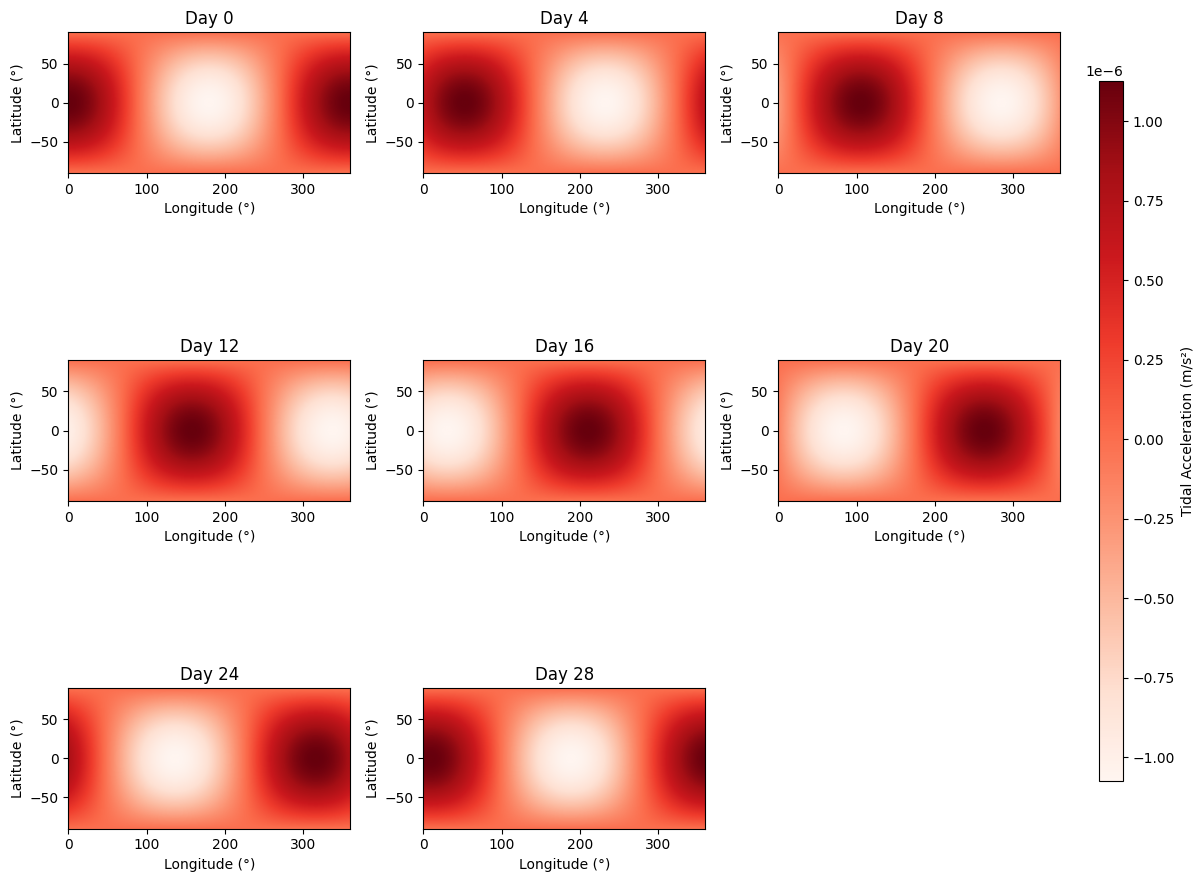

In [6]:
# Physical constants
G = 6.67430e-11
M_moon = 7.34767309e22
R_earth = 6.371e6
d_em = 384400e3
ecc = 0.055
T_moon = 27.3

# Time snapshots (0 to 28 days, step 4)
t_days = np.arange(0, 29, 4)
theta_orbit = 2*np.pi*t_days/T_moon

# Earth's surface grid
lat = np.linspace(-90, 90, 180)
lon = np.linspace(0, 360, 360)
lon_grid, lat_grid = np.meshgrid(lon, lat)

lat_rad = np.radians(lat_grid)
lon_rad = np.radians(lon_grid)

# Cartesian coordinates of Earth's surface
x = R_earth * np.cos(lat_rad) * np.cos(lon_rad)
y = R_earth * np.cos(lat_rad) * np.sin(lon_rad)
z = R_earth * np.sin(lat_rad)

# Function to compute tidal acceleration
def tidal_acc(x, y, z, x_m, y_m, z_m, M_moon):
    r_point = np.sqrt((x - x_m)**2 + (y - y_m)**2 + (z - z_m)**2)
    r_center = np.sqrt(x_m**2 + y_m**2 + z_m**2)
    return G*M_moon*(1/r_point**2 - 1/r_center**2)

# Plot tidal heat maps for each snapshot
plt.figure(figsize=(12, 10))

for i, th in enumerate(theta_orbit):
    # Moon position in circular orbit around Earth (XY plane)
    x_m = d_em * np.cos(th)
    y_m = d_em * np.sin(th)
    z_m = 0
    
    a_tidal = tidal_acc(x, y, z, x_m, y_m, z_m, M_moon)
    
    plt.subplot(3, 3, i+1)
    im = plt.imshow(a_tidal, extent=[0,360,-90,90], origin='lower',
                    cmap='Reds')
    plt.title(f"Day {t_days[i]}", fontsize=12)
    plt.xlabel("Longitude (°)", fontsize=10)
    plt.ylabel("Latitude (°)", fontsize=10)
    
# Single colorbar for reference
cbar_ax = plt.gcf().add_axes([0.92, 0.15, 0.02, 0.7])  # x, y, width, height
plt.colorbar(im, cax=cbar_ax, label="Tidal Acceleration (m/s²)")

plt.tight_layout(rect=[0,0,0.9,1])
plt.show()

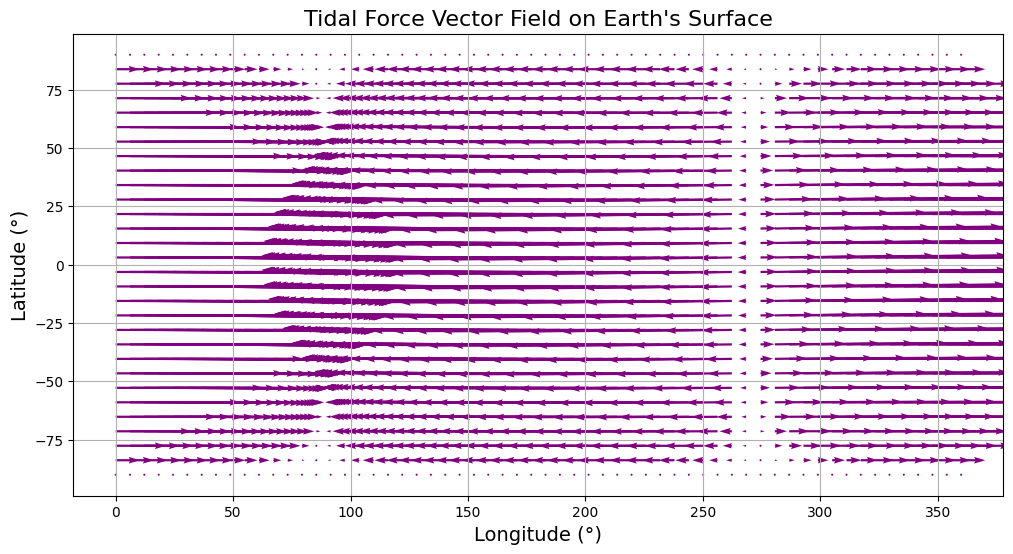

In [15]:
# Physical constants
G = 6.67430e-11         # gravitational constant [m^3 kg^-1 s^-2]
M_moon = 7.34767309e22  # Moon mass [kg]
R_earth = 6.371e6       # Earth radius [m]
d_em = 384400e3         # average Earth-Moon distance [m]
ecc = 0.055             # Moon's orbital eccentricity

# Moon's position in orbit
theta_orbit = 0  # snapshot (radians)
r_moon = d_em * (1 - ecc**2) / (1 + ecc * np.cos(theta_orbit))

# Earth's surface grid
lat = np.linspace(-90, 90, 30)   # fewer points for clarity
lon = np.linspace(0, 360, 60)
lon_grid, lat_grid = np.meshgrid(lon, lat)

lat_rad = np.radians(lat_grid)
lon_rad = np.radians(lon_grid)

# Cartesian coordinates of Earth's surface
x = R_earth * np.cos(lat_rad) * np.cos(lon_rad)
y = R_earth * np.cos(lat_rad) * np.sin(lon_rad)
z = R_earth * np.sin(lat_rad)

# Function to compute tidal vector components
def tidal_vector(x, y, z, r_moon, M_moon):
    
    # Compute 2D tidal acceleration vector components (ax, ay)
    # on Earth's surface projected onto XY plane.
    
    dx = r_moon - x  # vector from point to Moon along x
    dy = -y          # vector along y
    dz = -z          # vector along z
    
    r_point = np.sqrt(dx**2 + dy**2 + dz**2)
    r_center = r_moon
    
    # Tidal acceleration magnitude
    a_mag = G * M_moon * (1 / r_point**2 - 1 / r_center**2)
    
    # Direction in XY plane
    u = np.sqrt(dx**2 + dy**2)
    ux = dx / (u + 1e-12)  # avoid divide by zero
    uy = dy / (u + 1e-12)
    
    ax = a_mag * ux
    ay = a_mag * uy
    return ax, ay

# Compute tidal vectors
ax_vec, ay_vec = tidal_vector(x, y, z, r_moon, M_moon)

# Plot vector field
plt.figure(figsize=(12,6))
plt.quiver(lon_grid, lat_grid, ax_vec, ay_vec, color='purple', scale=5e-6)
plt.title("Tidal Force Vector Field on Earth's Surface", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=14)
plt.ylabel("Latitude (°)", fontsize=14)
plt.grid(True)
plt.show()

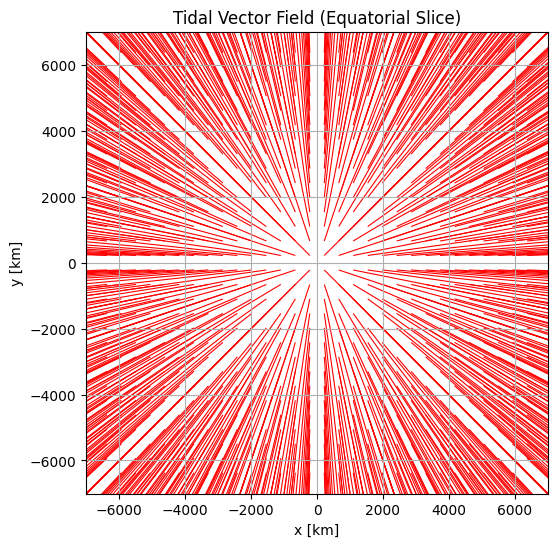

In [13]:
# Physical constants
G = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
M_earth = 5.972e24     # mass of Earth [kg]
M_moon = 7.348e22      # mass of Moon [kg]
R_earth_moon = 384400e3  # average Earth-Moon distance [m]
R_earth = 6371e3       # Earth's radius [m]

# Surface grid in equatorial plane
Nx, Ny = 30, 30  # grid resolution
x_vec = np.linspace(-R_earth, R_earth, Nx)
y_vec = np.linspace(-R_earth, R_earth, Ny)
X, Y = np.meshgrid(x_vec, y_vec)
R_vec = np.sqrt(X**2 + Y**2)  # radial distance from Earth's center


# Tidal acceleration (equatorial plane)
# a_tidal ~ 2 * G * M_moon * R / R_EM^3
A_x = 2 * G * M_moon * X / R_earth_moon**3
A_y = 2 * G * M_moon * Y / R_earth_moon**3

# Plot vector field
plt.figure(figsize=(6,6))
plt.quiver(X/1e3, Y/1e3, A_x*1e7, A_y*1e7, scale=5e-6, color='red')  # scaled for visibility
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Tidal Vector Field (Equatorial Slice)")
plt.grid(True)
plt.gca().set_aspect('equal')  # keep aspect ratio square
plt.show()

In [ ]:
# Constants
R_earth = 6.371e6        # Earth radius (m)
T_moon = 27.3            # Lunar period (days)
n_frames = 29            # 0 to 28
frame_gap = 4            # gap between frames

# Time frames for animation
frames_idx = np.arange(0, n_frames, frame_gap)
theta = 2 * np.pi * frames_idx / T_moon  # Moon orbital phase

# Earth's surface grid
lat = np.linspace(-np.pi/2, np.pi/2, 50)
lon = np.linspace(0, 2*np.pi, 100)
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Cartesian coordinates
x = R_earth * np.cos(lat_grid) * np.cos(lon_grid)
y = R_earth * np.cos(lat_grid) * np.sin(lon_grid)
z = R_earth * np.sin(lat_grid)

# Function to simulate tidal rise (sinusoidal, exaggerated for visibility)
def tide_height(theta_phase, lat_grid, lon_grid):
    # Tides strongest under Moon (theta_phase) and opposite side
    # Using cosine for longitudinal variation
    return 0.05 * R_earth * np.cos(lon_grid - theta_phase) * np.cos(lat_grid)

# Compute min/max tidal height for color scaling
tide_min = -0.05 * R_earth
tide_max = 0.05 * R_earth

# Generate frames
frames = []
for th in theta:
    z_tide = z + tide_height(th, lat_grid, lon_grid)
    frame = go.Frame(
        data=[go.Surface(
            x=x/1e6, y=y/1e6, z=z_tide/1e6,
            surfacecolor=tide_height(th, lat_grid, lon_grid),  # use normalized tide
            colorscale='Blues',
            cmin=tide_min, cmax=tide_max,
            colorbar=dict(title="Tide Rise (m)")
        )],
        name=f"t{int(th*180/np.pi)}"
    )
    frames.append(frame)

# Initial surface
z0_tide = z + tide_height(theta[0], lat_grid, lon_grid)

# Create figure
fig = go.Figure(
    data=[go.Surface(
        x=x/1e6, y=y/1e6, z=z0_tide/1e6,
        surfacecolor=tide_height(theta[0], lat_grid, lon_grid),
        colorscale='Blues',
        cmin=tide_min, cmax=tide_max,
        colorbar=dict(title="Tide Rise (m)")
    )],
    layout=go.Layout(
        title="Demo: Ocean Tides Rising and Falling",
        scene=dict(
            xaxis_title="X (10^6 m)",
            yaxis_title="Y (10^6 m)",
            zaxis_title="Z (10^6 m)",
            aspectmode='data'
        ),
        updatemenus=[dict(
            type="buttons",
            buttons=[
                dict(label="Play",
                     method="animate",
                     args=[None, {"frame": {"duration": 400, "redraw": True}, "fromcurrent": True}]),
                dict(label="Pause",
                     method="animate",
                     args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}])
            ]
        )]
    ),
    frames=frames
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/06-SEI-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/02-Planet-Packing.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-05-01.gif">